In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print("DataFrame head:")
display(df.head())
print("\nDataFrame info:")
df.info()

DataFrame head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Compute Descriptive Statistics


In [ ]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Skewed Distribution
.

Skewness of each numerical feature:


,0
sepal length (cm),0.314911
sepal width (cm),0.318966
petal length (cm),-0.274884
petal width (cm),-0.102967


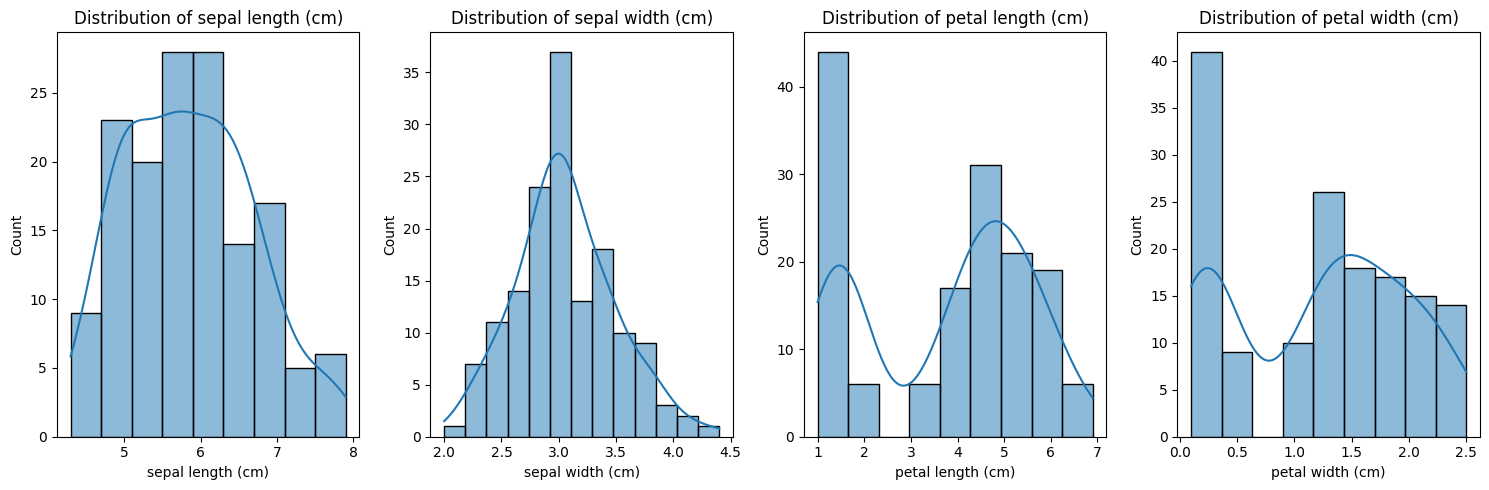

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Skewness of each numerical feature:")
numerical_features = df.select_dtypes(include=['float64', 'int64'])
display(numerical_features.skew())

fig, axes = plt.subplots(1, len(iris.feature_names), figsize=(15, 5))
for i, feature in enumerate(iris.feature_names):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Apply Z-score Normalization


Original 'sepal length (cm)' descriptive statistics:


,sepal length (cm)
count,150.000000
mean,5.843333
std,0.828066
min,4.300000
25%,5.100000
50%,5.800000
75%,6.400000
max,7.900000



Z-score normalized 'sepal length (cm)' descriptive statistics:


,sepal length (cm)_zscore
count,1.500000e+02
mean,-4.736952e-16
std,1.003350e+00
min,-1.870024e+00
25%,-9.006812e-01
50%,-5.250608e-02
75%,6.745011e-01
max,2.492019e+00


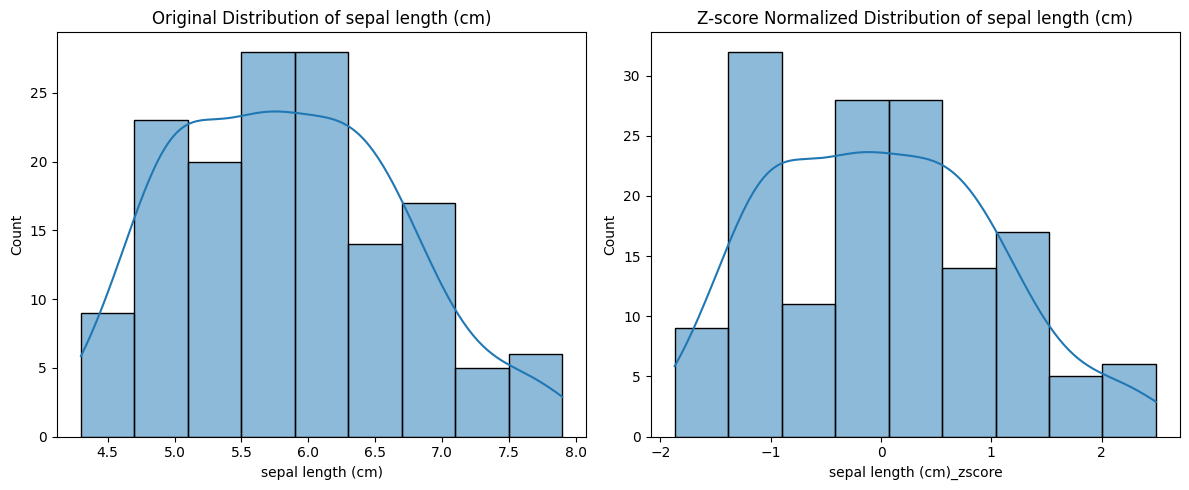

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

feature_to_normalize = 'sepal length (cm)'

df[f'{feature_to_normalize}_zscore'] = scaler.fit_transform(df[[feature_to_normalize]])

print(f"Original '{feature_to_normalize}' descriptive statistics:")
display(df[feature_to_normalize].describe())

print(f"\nZ-score normalized '{feature_to_normalize}' descriptive statistics:")
display(df[f'{feature_to_normalize}_zscore'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df[feature_to_normalize], kde=True, ax=axes[0])
axes[0].set_title(f'Original Distribution of {feature_to_normalize}')
sns.histplot(df[f'{feature_to_normalize}_zscore'], kde=True, ax=axes[1])
axes[1].set_title(f'Z-score Normalized Distribution of {feature_to_normalize}')
plt.tight_layout()
plt.show()

## Pearson and Spearman Correlation


Pearson Correlation Matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


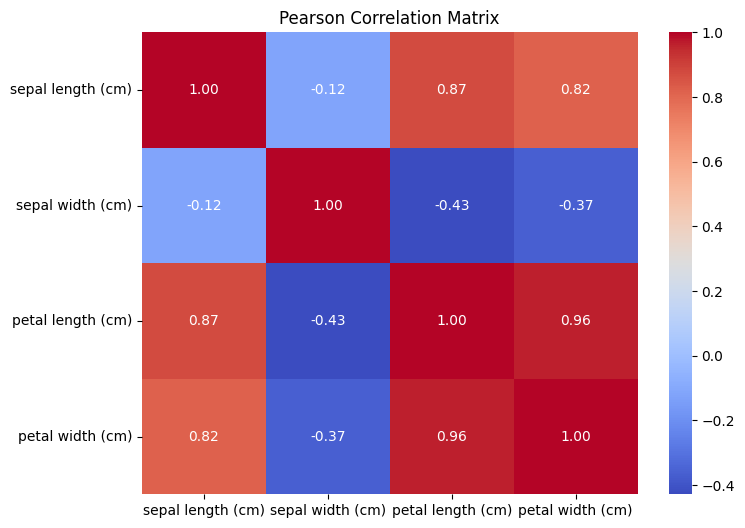


Spearman Correlation Matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.166778,0.881898,0.834289
sepal width (cm),-0.166778,1.000000,-0.309635,-0.289032
petal length (cm),0.881898,-0.309635,1.000000,0.937667
petal width (cm),0.834289,-0.289032,0.937667,1.000000


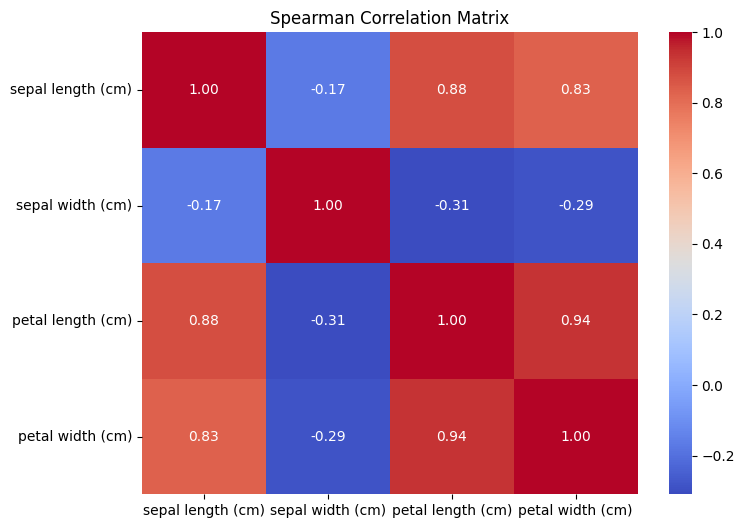

In [ ]:
numerical_df = df[iris.feature_names]

print("Pearson Correlation Matrix:")
pearson_corr = numerical_df.corr(method='pearson')
display(pearson_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

print("\nSpearman Correlation Matrix:")
spearman_corr = numerical_df.corr(method='spearman')
display(spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Matrix')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

#Load Titanic dataset
df =sns.load_dataset('titanic')
print(df.head())
print(df.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


In [ ]:
df.loc[0, 'embark_town'] = 'southampton'
df.loc[1, 'embark_town'] = 'SOUTHAMPTON'
df.loc[2, 'embark_town'] = 'Southampton'
print(df['embark_town'].unique())

['southampton' 'SOUTHAMPTON' 'Southampton' 'Queenstown' 'Cherbourg'
 'kingstown']


In [ ]:
df['embark_town'] = df['embark_town'].str.title()

In [ ]:
print(df['embark_town'].unique())


['Southampton' 'Queenstown' 'Cherbourg' nan]


In [ ]:
print(df['embark_town'].isnull().sum())

2


In [ ]:
df['embark_town'] =df['embark_town'].fillna('kingstown')


In [ ]:
print(df['embark_town'].unique())

['southampton' 'SOUTHAMPTON' 'Southampton' 'Queenstown' 'Cherbourg'
 'kingstown']


In [ ]:
# 1. Fill missing values with the most frequent value (mode)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
# 2. Verify that there are no missing values left
print("Missing values remaining:", df['embark_town'].isnull().sum())


Missing values remaining: 0


In [ ]:
#duplicate rows

duplicate_rows = df.iloc[:5]
df_dup = pd.concat([df, duplicate_rows])
print(df_dup.shape)

(896, 15)


In [ ]:
# Find Duplicate

print(df_dup.duplicated().sum())

112


In [ ]:
# View Duplicate Rows

df_dup[df_dup.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Southampton,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False


In [ ]:
# Remove Duplicate

df_dup = df_dup.drop_duplicates()
print(df_dup.duplicated().sum())

0


In [ ]:
#  3. Typos

df.loc[0, 'embark_town'] = 'Southampton'
df.loc[1, 'embark_town'] = 'southampton'


In [ ]:
print(df['embark_town'].value_counts())

embark_town
Southampton    644
Cherbourg      167
Queenstown      77
kingstown        2
southampton      1
Name: count, dtype: int64


In [ ]:
# Fix Typos
df['embark_town'] = df['embark_town'].replace({
    'Southampton', 'Southampton',
    'Southhampton', 'Southhampton'
})

/tmp/ipykernel_4300/2530226744.py:2: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df['embark_town'] = df['embark_town'].replace({


In [ ]:
# Verify:

print(df['embark_town'].value_counts())

embark_town
Southampton     644
Cherbourg       167
Queenstown       77
kingstown         2
southhampton      1
Name: count, dtype: int64


In [ ]:
#fix typos
df['embark_town']=df['embark_town'].replace({
    'Southamton':'Southampton',
    'Southhampton':'Southampton'})
#verfity:
print(df['embark_town'].value_counts())



embark_town
Southampton     644
Cherbourg       167
Queenstown       77
kingstown         2
southhampton      1
Name: count, dtype: int64


In [ ]:
#detect possible typos
print(sorted(df['embark_town'].dropna().unique()))

['Cherbourg', 'Queenstown', 'Southampton', 'kingstown', 'southampton']


In [ ]:
df.loc[0, 'age'] = 240
df.loc[1, 'age'] = 300

In [ ]:
# Detect Unusual Values
df['age'].describe()

,age
count,714.000000
mean,30.371387
std,19.362012
min,0.420000
25%,20.125000
50%,28.000000
75%,38.750000
max,300.000000


## Unit Mismatch

In [ ]:
df.loc[0,'age']=240
df.loc[1,'age']=300
df['age'].describe()



,age
count,714.000000
mean,30.371387
std,19.362012
min,0.420000
25%,20.125000
50%,28.000000
75%,38.750000
max,300.000000


In [ ]:
df.loc[df['age']>120,'age']=(df.loc[df['age']>120,'age']/12)
df['age'].describe()

,age
count,714.000000
mean,29.678109
std,14.525902
min,0.420000
25%,20.000000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
df['survived_label']=df['survived'].map({
    0:'No',
    1:'Yes'})
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  20.0      1      0   7.2500        S  Third   
1         1       1  female  25.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone survived_label  
0    man        True  NaN  Southampton    no  False             No  
1  woman       False    C  southampton   yes  False            Yes  
2  woman       False  NaN  Southampton   yes   True            Yes  
3  woman       False    C  Southampton   yes  False            Yes  
4    man        True  NaN  Southampton    no   True             No  


In [ ]:
df.isnull().mean()

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,0.198653
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.002245
class,0.000000
who,0.000000


In [ ]:
# Remove
df.drop(columns=['deck'], inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label
0,0,3,male,20.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,No
1,1,1,female,25.0,1,0,71.2833,C,First,woman,False,southampton,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,No


In [ ]:
# Check Missing Values
df.isnull().mean()

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,0.198653
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.002245
class,0.000000
who,0.000000


In [ ]:
# Method 1 : Mean Imputation

# Replace missing values with the average avlue.
df['age']=df['age'].fillna(df['age'].mean())
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label
0,0,3,male,20.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,No
1,1,1,female,25.000000,1,0,71.2833,C,First,woman,False,southampton,yes,False,Yes
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,No
5,0,3,male,29.678109,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,No
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,Southampton,no,True,No
7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,Southampton,no,False,No
8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,Yes
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,Yes


In [ ]:
print(df['embarked'].isnull().sum())

2


In [ ]:
# Apply Forward Fill

df['embarked_ffill'] = df['embarked'].ffill()

#Check Missing Values
print(df['embarked_ffill'].isnull().sum())

0


In [ ]:
import pandas as pd
import numpy as np
data = {
    'age': [22, 25, np.nan, 24, 23],
    'fare': [7.25, 8.05, 7.90, 8.00, 7.50]
}
df = pd.DataFrame(data)
print(df)

    age  fare
0  22.0  7.25
1  25.0  8.05
2   NaN  7.90
3  24.0  8.00
4  23.0  7.50


In [ ]:
from sklearn.impute import KNNImputer
KNN = KNNImputer(n_neighbors=3)
df_imputed = pd.DataFrame(
    KNN.fit_transform(df),
    columns=df.columns)
print(df_imputed)

    age  fare
0  22.0  7.25
1  25.0  8.05
2  24.0  7.90
3  24.0  8.00
4  23.0  7.50


In [ ]:
# check  Missing Values
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Forward Fill for embarked
df['embarked_ffill'] = df['embarked'].ffill()

# KNN Imputation for age
cols = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'pclass'
]
imputer = KNNImputer(n_neighbors=5)

df[cols] = imputer.fit_transform(df[cols])

print(df.isnull().mean())


survived          0.000000
pclass            0.000000
sex               0.000000
age               0.000000
sibsp             0.000000
parch             0.000000
fare              0.000000
embarked          0.002245
class             0.000000
who               0.000000
adult_male        0.000000
deck              0.772166
embark_town       0.002245
alive             0.000000
alone             0.000000
embarked_ffill    0.000000
dtype: float64


# Types of Encoding

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
df = sns.load_dataset('titanic')

#Labelc Encoding
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])

# One-Hot  Encoding
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

#Target Encoding
target_map = df.groupby('pclass')['survived'].mean()

df['class_target'] = (df['pclass'].map(target_map))
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare  class    who  \
0         0       3    male  22.0      1      0   7.2500  Third    man   
1         1       1  female  38.0      1      0  71.2833  First  woman   
2         1       3  female  26.0      0      0   7.9250  Third  woman   
3         1       1  female  35.0      1      0  53.1000  First  woman   
4         0       3    male  35.0      0      0   8.0500  Third    man   

   adult_male deck  embark_town alive  alone  sex_encoded  embarked_Q  \
0        True  NaN  Southampton    no  False            1       False   
1       False    C    Cherbourg   yes  False            0       False   
2       False  NaN  Southampton   yes   True            0       False   
3       False    C  Southampton   yes  False            0       False   
4        True  NaN  Southampton    no   True            1       False   

   embarked_S  class_target  
0        True      0.242363  
1       False      0.629630  
2        True      0.24236

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['age_minmax','fare_minmax']] = scaler.fit_transform(df[['age','fare']])
df[['age_minmax', 'fare_minmax']].head()

,age_minmax,fare_minmax
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


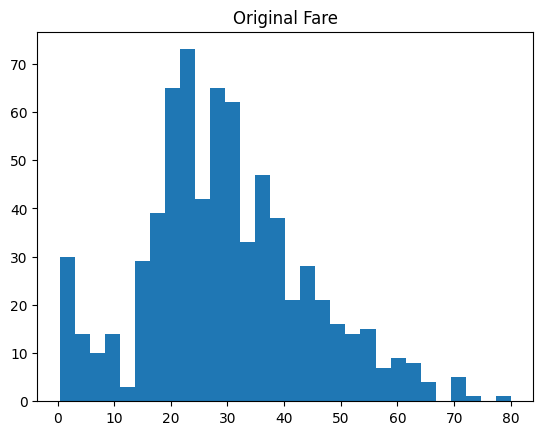

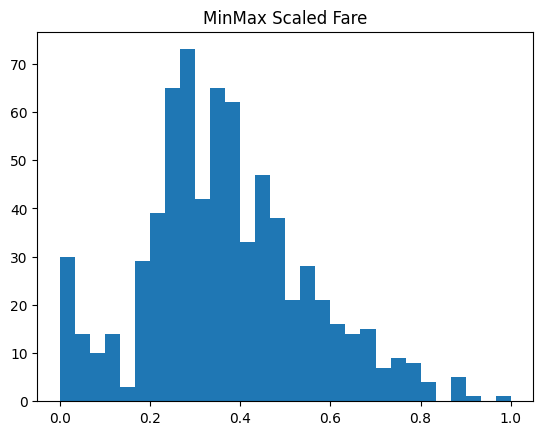

In [8]:
import matplotlib.pyplot as plt

plt.hist(df['age'].dropna(), bins=30)
plt.title("Original Fare")
plt.show()

plt.hist(df['age_minmax'].dropna(), bins=30)
plt.title("MinMax Scaled Fare")
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age_std','fare_std']] = scaler.fit_transform(
    df[['age','fare']])
df[['age_std', 'fare_std']].head()

,age_std,fare_std
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


In [11]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['age_robust','fare_robust']] = scaler.fit_transform(
    df[['age','fare']])
df[['age_robust', 'fare_robust']].head()

,age_robust,fare_robust
0,-0.335664,-0.312011
1,0.559441,2.461242
2,-0.111888,-0.282777
3,0.391608,1.673732
4,0.391608,-0.277363
